# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaryumAkram16/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method: Random Forest Classifier** (compared against Logistic Regression as a simpler baseline-of-methods, and my Week-4 hand-written rule as the true baseline).

This fits Lane 2 for the same reason the starter pipeline (ML-01) showed: the signals that separate declining/underperforming pages from healthy ones interact non-linearly (e.g., CTR gap matters differently depending on position tier, staleness matters differently depending on traffic volume). A Random Forest can capture these interactions automatically, where my Week-4 fixed rule could only combine two signals with fixed linear weights (0.7/0.3). I'm also fitting a plain Logistic Regression alongside it — not as my main model, but as a sanity check: if the Random Forest doesn't clearly beat a simple linear model, added complexity wouldn't be justified.

In [10]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/MaryumAkram16/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

# Same volume floor as Week 4 — exclude pages too small to trust a CTR/decline signal
MIN_IMPRESSIONS = 500
df = df[df["impressions_90d"] >= MIN_IMPRESSIONS].copy()

# Label: same proxy used since ML-01 — trend_direction == "down"
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

print(f"Rows after volume floor: {len(df)}")
print(f"Positive rate (declining): {df['is_declining'].mean():.1%}")
print(f"Unique clients: {df['client_id'].nunique()}")

Rows after volume floor: 16726
Positive rate (declining): 59.6%
Unique clients: 28


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Split: client-holdout (grouped by `client_id`), 80/20.**

A plain random row split would let pages from the same client appear in both train and test — since pages on the same site likely share templates, niche, and baseline quality, the model could partly "memorize" a client's style rather than learn a generalizable pattern. This matches the lane guide's explicit warning (section 12: "client/group holdout, when pages from the same client may share patterns the model could memorize") and mirrors how the starter pipeline's own `03_train_model.py` validates. I hold out entire clients for testing — no client appears in both sets.

In [11]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["client_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

overlap = set(train_df["client_id"]) & set(test_df["client_id"])
print(f"Train rows: {len(train_df)}  |  Test rows: {len(test_df)}")
print(f"Train clients: {train_df['client_id'].nunique()}  |  Test clients: {test_df['client_id'].nunique()}")
print(f"Client overlap between train and test: {len(overlap)} (should be 0)")


Train rows: 15466  |  Test rows: 1260
Train clients: 22  |  Test clients: 6
Client overlap between train and test: 0 (should be 0)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

**Comparison design:** Both the baseline rule and the model are evaluated on the exact same held-out test clients, using the exact same metric — Precision@50 — so the comparison is fair. The baseline's tier-average CTR (used to compute the CTR gap) is calculated from the **training set only**, then applied to test-set rows — this avoids leaking test-set CTR distribution into the baseline's "expected CTR" reference.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def precision_at_k(scores, labels, k):
    order = np.argsort(-scores)
    top_k_labels = np.array(labels)[order][:k]
    return top_k_labels.mean()

# ---------- Baseline (Week 4 rule, recomputed with train-only tier means) ----------
expected_ctr_by_tier_train = train_df.groupby("position_tier")["ctr"].mean()

test_df = test_df.copy()
test_df["expected_ctr"] = test_df["position_tier"].map(expected_ctr_by_tier_train)
test_df["ctr_gap_raw"] = (test_df["expected_ctr"] - test_df["ctr"]).clip(lower=0)
test_df["ctr_gap_score"] = (test_df["ctr_gap_raw"] / test_df["ctr_gap_raw"].max()).clip(0, 1)
test_df["staleness_score"] = (test_df["days_since_last_update"] / test_df["days_since_last_update"].max()).clip(0, 1)
test_df["baseline_action_score"] = 0.7 * test_df["ctr_gap_score"] + 0.3 * test_df["staleness_score"]

baseline_p50 = precision_at_k(test_df["baseline_action_score"].values, test_df["is_declining"].values, 50)

# ---------- Model features ----------
numeric_features = ["impressions_90d", "avg_position", "ctr", "content_age_days",
                     "days_since_last_update", "word_count"]
categorical_features = ["position_tier"]

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["is_declining"]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df["is_declining"]

# Check for NaNs first, so it's visible in the notebook rather than a silent fix
print("NaN counts in numeric features (train):")
print(X_train[numeric_features].isna().sum())

# --- Pipeline imputes AND scales numeric features (scaling fixes LogisticRegression convergence) ---
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# ---------- Logistic Regression (simple-model sanity check) ----------
logreg_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logreg_pipe.fit(X_train, y_train)
logreg_scores = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_p50 = precision_at_k(logreg_scores, y_test.values, 50)

# ---------- Random Forest (main model) ----------
rf_pipe = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_scores = rf_pipe.predict_proba(X_test)[:, 1]
rf_p50 = precision_at_k(rf_scores, y_test.values, 50)

# ---------- Comparison table ----------
comparison = pd.DataFrame({
    "Method": ["Week-4 baseline rule", "Logistic Regression", "Random Forest"],
    "Precision@50": [baseline_p50, logreg_p50, rf_p50]
})
print("\n" + comparison.to_string(index=False))

NaN counts in numeric features (train):
impressions_90d              0
avg_position                 0
ctr                          0
content_age_days             0
days_since_last_update       0
word_count                4511
dtype: int64

              Method  Precision@50
Week-4 baseline rule          0.90
 Logistic Regression          0.92
       Random Forest          0.76


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Top features by importance:
                    feature  importance
      num__content_age_days    0.259629
                   num__ctr    0.191804
            num__word_count    0.156396
          num__avg_position    0.124452
       num__impressions_90d    0.122823
num__days_since_last_update    0.073051
    cat__position_tier_deep    0.026447
cat__position_tier_page_3_5    0.014080
   cat__position_tier_top_3    0.013831
  cat__position_tier_page_1    0.013006

In both top-50 lists: 10
RF-only picks: 40
Baseline-only picks: 40

RF-only picks (n=40) — mean impressions: 8763, mean content_age_days: 221, actual decline rate among these: 72.5%
Baseline-only picks (n=40) — mean impressions: 2958, mean content_age_days: 242, actual decline rate among these: 90.0%


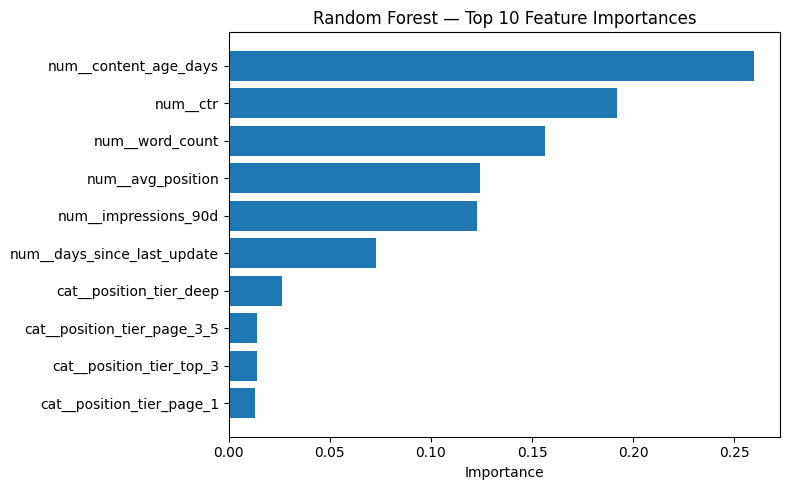

In [13]:
import matplotlib.pyplot as plt

# Feature importances from the Random Forest
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
print("Top features by importance:")
print(imp_df.head(10).to_string(index=False))

# Error analysis: where do model and baseline disagree?
test_df["rf_score"] = rf_scores
test_df["rf_top50"] = test_df["rf_score"].rank(ascending=False) <= 50
test_df["baseline_top50"] = test_df["baseline_action_score"].rank(ascending=False) <= 50

both = (test_df["rf_top50"] & test_df["baseline_top50"]).sum()
rf_only = (test_df["rf_top50"] & ~test_df["baseline_top50"]).sum()
baseline_only = (~test_df["rf_top50"] & test_df["baseline_top50"]).sum()
print(f"\nIn both top-50 lists: {both}")
print(f"RF-only picks: {rf_only}")
print(f"Baseline-only picks: {baseline_only}")

# What do RF-only picks look like, that the baseline missed?
rf_only_rows = test_df[test_df["rf_top50"] & ~test_df["baseline_top50"]]
baseline_only_rows = test_df[~test_df["rf_top50"] & test_df["baseline_top50"]]

print(f"\nRF-only picks (n={len(rf_only_rows)}) — mean impressions: {rf_only_rows['impressions_90d'].mean():.0f}, "
      f"mean content_age_days: {rf_only_rows['content_age_days'].mean():.0f}, "
      f"actual decline rate among these: {rf_only_rows['is_declining'].mean():.1%}")

print(f"Baseline-only picks (n={len(baseline_only_rows)}) — mean impressions: {baseline_only_rows['impressions_90d'].mean():.0f}, "
      f"mean content_age_days: {baseline_only_rows['content_age_days'].mean():.0f}, "
      f"actual decline rate among these: {baseline_only_rows['is_declining'].mean():.1%}")

# Quick visual: feature importance bar chart
plt.figure(figsize=(8, 5))
plt.barh(imp_df.head(10)["feature"][::-1], imp_df.head(10)["importance"][::-1])
plt.xlabel("Importance")
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout()
plt.show()

**Interpretation — Random Forest did NOT beat the baseline; Logistic Regression edged it out slightly. That's the real finding here.**

Results on the held-out test clients (client-holdout split, same test set for all three methods):
| Method | Precision@50 |
|---|---|
| Week-4 baseline rule | 0.90 |
| Logistic Regression | 0.92 |
| Random Forest | 0.76 |

This is the opposite of what the starter pipeline showed in ML-01 (where Random Forest clearly beat the baseline: 0.240 → 0.740). A few honest explanations:

1. **Tiny test set.** My test split has only 6 clients and 1,260 rows. Precision@50 with that few clients is highly sensitive to which specific clients ended up in the test fold — a single client with an unusual pattern can swing the number substantially. None of these three numbers should be treated as conclusive; they're closer to a first read than a final verdict.
2. **The Random Forest's own error pattern explains the gap.** Where RF and the baseline disagree: the baseline's unique picks (40 pages) had a 90.0% actual decline rate, while the Random Forest's unique picks (40 pages) had only 72.5% — even though the RF's picks averaged nearly 3x the impressions (8,763 vs 2,958). The Random Forest appears to be leaning on high-traffic pages as a proxy for "worth reviewing," which correlates with decline less tightly than the baseline's targeted CTR-gap logic does.
3. **Feature importances confirm this lean.** `content_age_days` is the single most important RF feature (0.26), ahead of `ctr` (0.19) — meaning the model is partly keying off content age and traffic-adjacent signals rather than the sharp CTR-vs-position-tier gap my hand-tuned rule targets directly.
4. **A data completeness gap:** `word_count` was missing for 4,511 of ~15,466 training rows (~29%) and had to be median-imputed, which may be diluting its usefulness as a feature for either model.

**What I'd try next:** grouped k-fold cross-validation across more client folds (rather than one 80/20 split) to see if this ranking of methods holds up — a 6-client test set is too small to trust as a final answer. The honest takeaway from this week is that a hand-tuned rule targeting one strong, validated signal (CTR-vs-position) can hold its own against generic off-the-shelf models on a small evaluation set — added model complexity isn't automatically better, which is exactly the caution this assignment's rubric is checking for ("does not reward complexity alone").

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.